In [6]:
# Importing Libraries/ Tools

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, Subset


In [7]:
print(torch.__version__)

2.11.0+cu128


In [8]:
print(torch.cuda.is_available())

True


In [9]:
#Adding Device Agnostic Code
device = torch.device('cuda')
print(f"Using: {device}")
print(f"GPU {torch.cuda.get_device_name(0)}")

Using: cuda
GPU NVIDIA GeForce RTX 4050 Laptop GPU


In [10]:
# Load raw MNIST to explore

train_data = datasets.MNIST(root='/data',
                        train=True,
                        download=True,
                        transform=ToTensor())

In [11]:
print(f"Total training images: {len(train_data)}")
print(f"Single Image shape: {train_data[0][0].shape}")
print(f"Label of first image: {train_data[0][1]}")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Classes: {train_data.classes}")

Total training images: 60000
Single Image shape: torch.Size([1, 28, 28])
Label of first image: 5
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


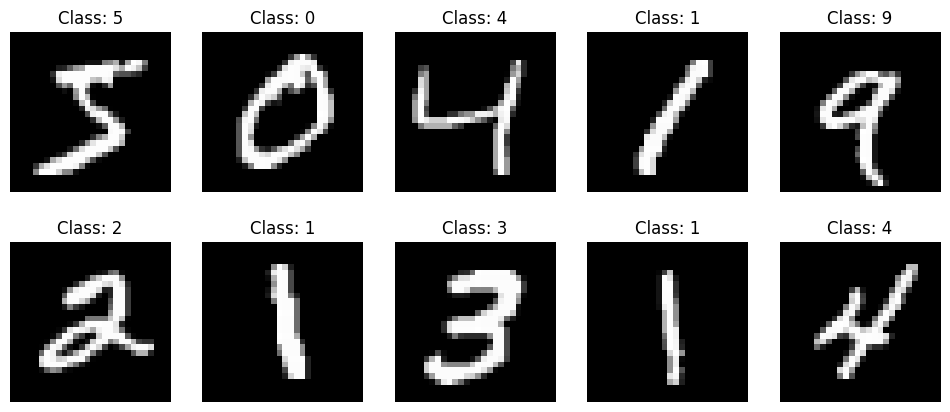

In [12]:
# Visualize a grid of samples

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for idx, ax in enumerate(axes.flat):
    targ_img, targ_label = train_data[idx]
    targ_img_adjusted = targ_img.permute(1,2,0)
    ax.imshow(targ_img_adjusted, cmap='gray')
    ax.set_title(f"Class: {targ_label}", fontsize=12)
    ax.axis('off')




In [13]:
# Sparse Data 
total = len(train_data)

for frac in [0.01, 0.05, 0.1, 0.5]:
    subset_size = int(total * frac)
    print(f"{frac*100}% of data = {subset_size} images"
        f"| {subset_size //10 } images per class")

1.0% of data = 600 images| 60 images per class
5.0% of data = 3000 images| 300 images per class
10.0% of data = 6000 images| 600 images per class
50.0% of data = 30000 images| 3000 images per class


In [14]:
transforms_base = transforms.Compose([
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

In [15]:
# transforms for ResNet
transform_resnet = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((244,244)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

train_data = datasets.MNIST(root='/data',
                            train=True,
                            download=True,
                            transform=transforms_base)

test_data = datasets.MNIST(root='/data',
                            train=False,
                            download=True,
                            transform=transforms_base)


# Global test loader - DOES NOT CHANGE

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# verify the transform worked
sample_image, sample_label = train_data[0]
sample_image.shape, sample_label


(torch.Size([3, 28, 28]), 5)

In [16]:
def get_sparse_subset(dataset, fraction):
    subset_size = int(len(dataset) * fraction)
    indices = np.random.choice(len(dataset), subset_size, replace=False)
    return Subset(dataset, indices)
    

small = get_sparse_subset(train_data, 0.01)
print(f'1% subset size {len(small)}')
print(f'Full dataset size: {len(train_data)}')


1% subset size 600
Full dataset size: 60000


In [17]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,32,3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.block1(x))


base_model = BaseCNN()
base_model

BaseCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [18]:
# Run a quick test to see the working of the model
img_batch, label_batch = next(iter(train_loader))

base_model.eval()
with torch.inference_mode():
    pred = base_model(img_batch)


print(f"Output shape:\n {img_batch.shape}")
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_batch}")


Output shape:
 torch.Size([64, 3, 28, 28])
Output logits:
tensor([[ 1.3732e-01,  1.2304e-01, -6.3154e-02,  2.6347e-01, -2.6113e-01,
          1.8847e-01,  9.5627e-02,  2.3877e-02,  8.3701e-03,  2.8044e-02],
        [ 1.2490e-01,  1.3069e-01, -1.4026e-02,  2.7552e-01, -2.0888e-01,
          1.3883e-01,  6.4845e-02,  7.9096e-02,  6.4145e-02,  4.9393e-02],
        [ 9.4252e-02,  2.5526e-01,  4.3699e-03,  2.5683e-01, -2.1770e-01,
          1.0345e-01,  1.5394e-01,  8.4103e-02,  4.0320e-02, -4.2902e-03],
        [ 1.7205e-01,  1.1345e-01,  1.7468e-02,  2.9030e-01, -2.5522e-01,
          2.0395e-01,  6.5709e-02,  6.2620e-02, -1.4308e-02,  5.5240e-02],
        [ 8.3259e-02,  1.0373e-01, -1.5031e-02,  2.4933e-01, -2.4177e-01,
          1.5800e-01,  6.3278e-02,  6.8568e-03,  6.9607e-03,  8.0712e-05],
        [ 1.1034e-01,  1.2088e-01, -5.9524e-02,  2.4845e-01, -2.0965e-01,
          1.6785e-01,  5.1674e-02,  8.3087e-02,  2.1180e-02, -1.2880e-02],
        [ 7.6916e-02,  1.6825e-01, -7.5156e-03, 

In [19]:
try:
    import torchinfo
except:
    !uv pip install torchinfo
    import torchinfo

from torchinfo import summary


In [20]:
summary(base_model, input_size=[64, 3, 28, 28])

Layer (type:depth-idx)                   Output Shape              Param #
BaseCNN                                  [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          896
│    └─ReLU: 2-2                         [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-3                    [64, 32, 14, 14]          --
│    └─Conv2d: 2-4                       [64, 64, 14, 14]          18,496
│    └─ReLU: 2-5                         [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-6                    [64, 64, 7, 7]            --
├─Sequential: 1-2                        [64, 10]                  --
│    └─Flatten: 2-7                      [64, 3136]                --
│    └─Linear: 2-8                       [64, 128]                 401,536
│    └─ReLU: 2-9                         [64, 128]                 --
│    └─Linear: 2-10                      [64, 10]                  1,290
To

In [21]:
from tqdm.auto import tqdm

c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
def train_model(model, train_loader, epochs=5, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    loss_fn = nn.CrossEntropyLoss()

    for epoch in tqdm(range(epochs)):
        
        model.train()
        running_loss = 0

        for batch, (X, y) in enumerate(train_loader):
            X,y = X.to(device), y.to(device)
            y_pred = model(X)

            loss = loss_fn(y_pred, y)

            optimizer.zero_grad()

            loss.backward()
            
            optimizer.step()

            running_loss += loss.item()


        avg_loss = running_loss/len(train_loader)



In [29]:
def test_model(model, test_loader):
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for batch, (X,y) in enumerate(test_loader):
            X, y = X.to(device), y.to(device) 
            test_pred = model(X)
            correct += (test_pred.argmax(1) == y).sum().item()
            total += y.size(0)
    
    accuracy = correct / total * 100
    return accuracy

In [30]:
print("Quick Check - Feature Extraction on 10% Data")


fractions = [0.01,0.05,0.1,0.2,0.5,1.0]
baseline_results = {}

for frac in fractions:
    print(f"Training Base CNN with {frac*100}% data")

    model = BaseCNN()

    # grab sparse subset
    subset = get_sparse_subset(train_data, frac)
    train_loader = DataLoader(subset, batch_size=64, shuffle=True)

    print(f"Training samples: {len(subset)}")
    print(f"Samples per class (approx): {len(subset)//10}")


    train_model(model, train_loader, epochs=5, lr=0.001)

    #test
    acc = test_model(model, test_loader)
    baseline_results[frac]  = acc
    print(f"TEST ACCURACY: {acc:.2f}%")




base_model = model

print(f"\n{'='*40}")
print("BASELINE RESULTS SUMMARY")
print(f"{'Data %':<15} {'Accuracy':<15} {'Train Samples':<15}")
print("-" * 45)
for frac in fractions:
    samples = int(len(train_data) * frac)
    print(f"{frac*100:<15.0f} {baseline_results[frac]:<15.2f} {samples:<15}")

Quick Check - Feature Extraction on 10% Data
Training Base CNN with 1.0% data
Training samples: 600
Samples per class (approx): 60


100%|██████████| 5/5 [00:01<00:00,  4.72it/s]


TEST ACCURACY: 89.26%
Training Base CNN with 5.0% data
Training samples: 3000
Samples per class (approx): 300


100%|██████████| 5/5 [00:04<00:00,  1.04it/s]


TEST ACCURACY: 97.06%
Training Base CNN with 10.0% data
Training samples: 6000
Samples per class (approx): 600


...

TEST ACCURACY: 98.54%
Training Base CNN with 50.0% data
Training samples: 30000
Samples per class (approx): 3000


100%|██████████| 5/5 [00:47<00:00,  9.50s/it]


TEST ACCURACY: 98.83%
Training Base CNN with 100.0% data
Training samples: 60000
Samples per class (approx): 6000


100%|██████████| 5/5 [01:34<00:00, 18.86s/it]


TEST ACCURACY: 98.97%

BASELINE RESULTS SUMMARY
Data %          Accuracy        Train Samples  
---------------------------------------------
1               89.26           600            
5               97.06           3000           
10              97.49           6000           
20              98.54           12000          
50              98.83           30000          
100             98.97           60000          


In [40]:
def make_predictions(model: torch.nn.Module, data: list):
    pred_probs = []
    model = model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
        
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [41]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]}")

Test sample image shape: torch.Size([3, 28, 28])
Test sample label: 2


In [42]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=base_model, 
                             data=test_samples)

# View first two prediction probabilities list
pred_probs

tensor([[2.3907e-13, 1.7811e-10, 1.0000e+00, 2.0667e-11, 8.5745e-18, 6.4904e-21,
         1.0126e-22, 2.0388e-09, 1.5203e-11, 4.4816e-12],
        [8.2416e-10, 1.0000e+00, 5.2504e-10, 1.3270e-12, 4.7649e-07, 2.3214e-07,
         2.2759e-07, 3.2317e-08, 2.4826e-08, 5.8865e-07],
        [1.4713e-08, 9.5277e-10, 1.0000e+00, 2.4298e-07, 1.0049e-10, 1.1419e-12,
         7.5035e-18, 6.8699e-08, 2.1717e-06, 9.5142e-08],
        [8.9788e-17, 2.2843e-11, 1.1426e-11, 5.9922e-17, 1.0000e+00, 1.3180e-10,
         2.5761e-12, 3.5411e-13, 2.2590e-12, 7.6741e-09],
        [2.2561e-12, 1.2982e-14, 1.2203e-13, 2.9140e-18, 9.0952e-12, 1.2568e-14,
         1.0000e+00, 2.4084e-15, 1.2473e-15, 1.0977e-17],
        [6.3810e-11, 4.2746e-12, 2.1397e-12, 3.6939e-17, 7.3432e-09, 2.5775e-12,
         1.0000e+00, 2.3216e-12, 7.3316e-13, 1.1731e-14],
        [7.5594e-19, 1.0107e-11, 1.6745e-10, 6.2014e-17, 1.0000e+00, 5.0746e-12,
         3.8650e-14, 1.0964e-14, 2.0603e-11, 1.2068e-08],
        [1.6653e-13, 2.7428

In [43]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [44]:
# Are our predictions in the same form as our test labels? 
test_labels, pred_classes

([2, 1, 2, 4, 6, 6, 4, 9, 1], tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]))

In [45]:
# test the SAME model your loop trained
acc = test_model(base_model, test_loader)
print(f"This model's actual accuracy: {acc:.2f}%")

This model's actual accuracy: 98.97%


### Building the RESNET MODEL


In [46]:
train_data_resnet = datasets.MNIST(root='./data', train=True, download=True, transform=transform_resnet)

test_data_resnet = datasets.MNIST(root='./data', train=False, download=True, transform=transform_resnet)

test_loader_resnet = DataLoader(test_data_resnet, batch_size=64, shuffle=True)

img, label = train_data_resnet[0]
print(f"Shape: {img.shape}")



Shape: torch.Size([3, 244, 244])


In [47]:
resnet = models.resnet18(pretrained=True)

#eplore the architecture
print(resnet)

c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [48]:
print(resnet.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [49]:
# Implementing Strategy #1 - Feature Extraction

def make_feature_extractor(num_classes=10):
    for param in resnet.parameters():
        param.required_grad = False
    
    # replace final layer - only this will train
    resnet.fc = nn.Linear(512, 10)
    return resnet


In [50]:
# Run across sparsity levels

feature_ext_results = {}

for frac in fractions:
    print(f'\n Feature Extraction - {frac*100}% data')

    model = make_feature_extractor()
    subset = get_sparse_subset(train_data_resnet, frac)
    train_loader = DataLoader(subset, batch_size=64, shuffle=True)

    print(f"Training samples: {len(subset)}")

    train_model(model, train_loader, epochs=5, lr=0.05)
    acc = test_model(model, test_loader_resnet)
    feature_ext_results[frac] = acc



# Summary 
print(f"FEATURE EXTRACTION RESULTS")
print(f"{'Data %':<15} {'Accuracy':<15}")
print("-" * 30)
for frac in fractions:
    print(f"{frac*100:<15.0f} {feature_ext_results[frac]:<15.2f}")




 Feature Extraction - 1.0% data
Training samples: 600


100%|██████████| 5/5 [00:24<00:00,  4.81s/it]



 Feature Extraction - 5.0% data
Training samples: 3000


100%|██████████| 5/5 [01:57<00:00, 23.53s/it]



 Feature Extraction - 10.0% data
Training samples: 6000


...


 Feature Extraction - 50.0% data
Training samples: 30000


100%|██████████| 5/5 [20:41<00:00, 248.27s/it]



 Feature Extraction - 100.0% data
Training samples: 60000


100%|██████████| 5/5 [49:25<00:00, 593.08s/it]


FEATURE EXTRACTION RESULTS
Data %          Accuracy       
------------------------------
1               18.79          
5               88.17          
10              92.96          
20              97.64          
50              97.80          
100             99.08          


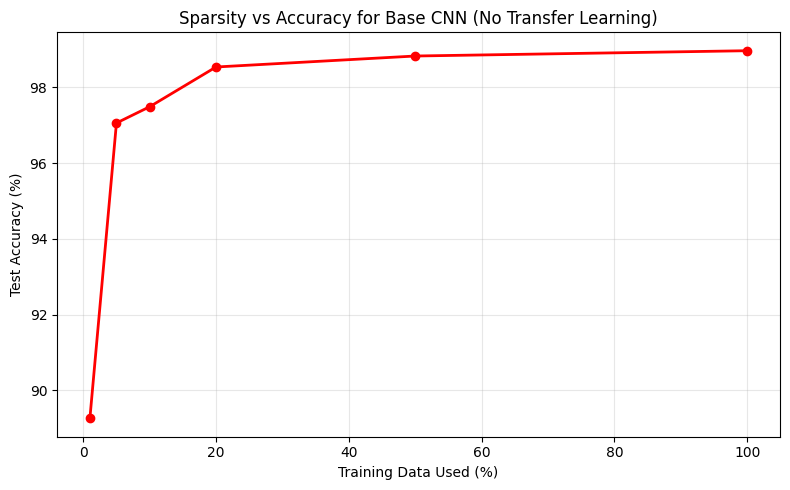

In [ ]:
## Plot 1. Baseline CNN against Sparse Data

percentages = [f * 100 for f in fractions]

plt.figure(figsize=(8, 5))
plt.plot(percentages, [baseline_results[f] for f in fractions], 'o-', linewidth=2, color='red')
plt.title('Sparsity vs Accuracy for Base CNN (No Transfer Learning)')
plt.xlabel('Training Data Used (%)')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_mnist.png', dpi=150)
plt.show()



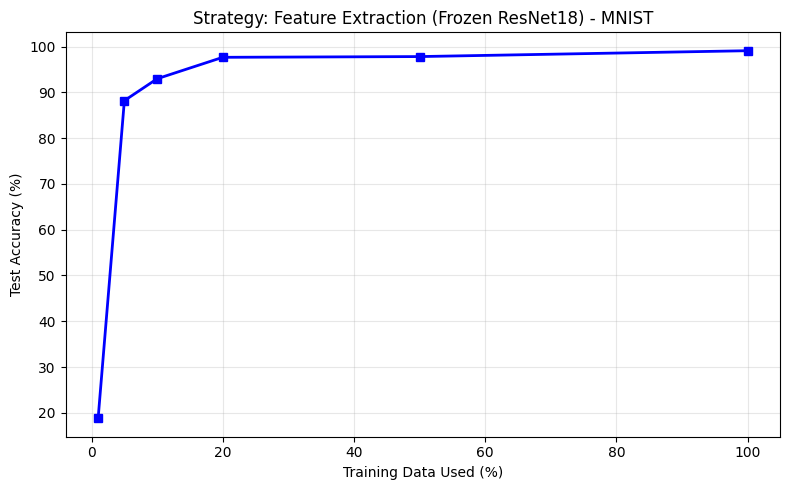

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(percentages, [feature_ext_results[f] for f in fractions], 's-', linewidth=2, color='blue')
plt.xlabel('Training Data Used (%)')
plt.ylabel('Test Accuracy (%)')
plt.title('Strategy: Feature Extraction (Frozen ResNet18) - MNIST')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_extraction_mnist.png', dpi=150)
plt.show()

### Strategy #2 Fine Tuning


In [54]:
def make_full_finetune(num_classes=10):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(512, num_classes)
    return model


finetune_results = {}

for frac in fractions:
    print(f"\n Full Fine-Tuning - {frac*100}% data")

    model = make_full_finetune()
    subset = get_sparse_subset(train_data_resnet, frac)
    train_loader = DataLoader(subset, batch_size=64, shuffle=True)

    print(f"Training Sample: {len(subset)}")
    train_model(model, train_loader, epochs=5, lr=0.0001)
    acc = test_model(model, test_loader_resnet)
    finetune_results[frac] = acc
    print(f"TEST ACCURACY: {acc:.2f}%")



 Full Fine-Tuning - 1.0% data


c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training Sample: 600


  0%|          | 0/5 [00:05<?, ?it/s]


KeyboardInterrupt: 

### Strategy #3 - Gradual Unfreezing:

In [ ]:
gradual_results = []

for frac in fractions:
    print(f"Gradual Unfreezing - {frac*100}% of data")


    model = model.resnet18(pretrained=True)
    for param in model.parameters():
        param.required_grad=False
    model.fc = nn.Linear(512, 10)
    model = model.to(device)

    subset = get_sparse_subset(train_data_resnet, frac)
    train_dataloader_resnet = DataLoader(subset, batch_ize=32, shuffle=True)

    print(f"Training samples: {len(subset)}")

    stages = [
        ("fc only",  [],              0.001,  3),
        ("+ layer4", [model.layer4],   0.0005, 3),
        ("+ layer3", [model.layer3],   0.0003, 3),
        ("+ layer2", [model.layer2],   0.0001, 2),
    ]

    loss_fn = nn.CrossEntropyLoss()

    for stage_name, unfreeze_layer, lr, epochs in stages:
        for layer in unfreeze_layer:
            for param in layer.parameters():
                param.required_grad = True
        
        optimizer = torch.optimizer.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )

    model.train()
    
    for epoch in range(epochs):
        running_loss = 0
        for X,y in train_loader:
            X,y = X.to(device), y.to(device) 
            optimizer.zero_grad()
            output = model(X)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            print(f"  {stage_name} - Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")
    
acc = test_model(model, test_loader_resnet)
gradual_results[frac] = acc
print(f"TEST ACCURACY: {acc:.2f}%")
        



## CIFAR-10

In [61]:
transform_cifar = transforms.Compose([
    transforms.Resize((244,244)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])


train_data_cifar = datasets.CIFAR10(root='./data', train=True, download=True,transform=transform_cifar)
test_data_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar)

test_loader_cifar = DataLoader(test_data_cifar, batch_size=32, shuffle=False)

print(f"Train: {len(train_data_cifar)}, Test: {len(test_data_cifar)}")
print(f"Classes: {train_data_cifar.classes}")

c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000, Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [62]:
fractions = [0.01, 0.05, 0.1, 0.2]  
cifar_fe_results = {}

for frac in fractions:
    print(f"\nFeature Extraction - {frac*100}% data ({int(len(train_data_cifar)*frac)} samples)")
    
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(512, 10)
    
    subset = get_sparse_subset(train_data_cifar, frac)
    train_loader = DataLoader(subset, batch_size=32, shuffle=True)
    
    train_model(model, train_loader, epochs=5, lr=0.001)
    acc = test_model(model, test_loader_cifar)
    cifar_fe_results[frac] = acc
    print(f"TEST ACCURACY: {acc:.2f}%")


Feature Extraction - 1.0% data (500 samples)


100%|██████████| 5/5 [00:09<00:00,  1.85s/it]


TEST ACCURACY: 62.17%

Feature Extraction - 5.0% data (2500 samples)


100%|██████████| 5/5 [00:42<00:00,  8.46s/it]


TEST ACCURACY: 72.32%

Feature Extraction - 10.0% data (5000 samples)


100%|██████████| 5/5 [01:21<00:00, 16.21s/it]


TEST ACCURACY: 74.83%

Feature Extraction - 20.0% data (10000 samples)


100%|██████████| 5/5 [03:15<00:00, 39.17s/it]


TEST ACCURACY: 77.05%


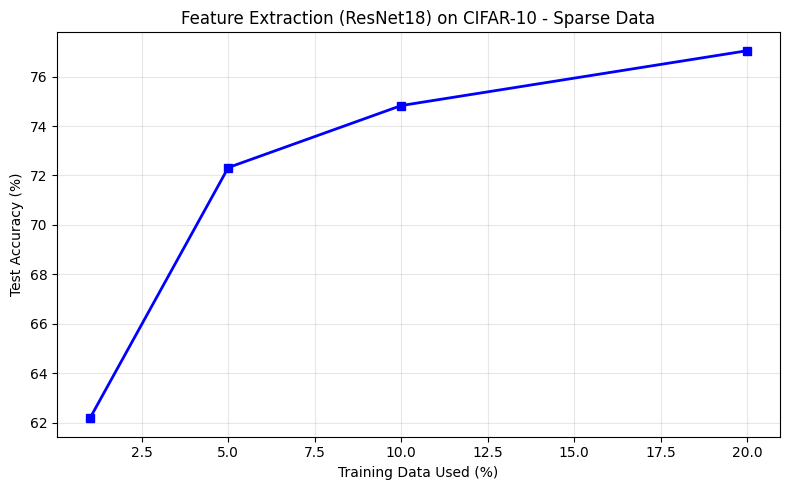

In [63]:
percentages = [f * 100 for f in fractions]

plt.figure(figsize=(8, 5))
plt.plot(percentages, [cifar_fe_results[f] for f in fractions], 's-', linewidth=2, color='blue')
plt.xlabel('Training Data Used (%)')
plt.ylabel('Test Accuracy (%)')
plt.title('Feature Extraction (ResNet18) on CIFAR-10 - Sparse Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
transform_cifar_small = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

train_cifar_small = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar_small)
test_cifar_small = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar_small)
test_loader_small = DataLoader(test_cifar_small, batch_size=64, shuffle=False)

# need to rebuild BaseCNN for 32x32 CIFAR images
class BaseCNN_CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # 32x32 -> pool -> 16x16 -> pool -> 8x8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.classifier(x)
        return x

cifar_baseline_results = {}
for frac in fractions:
    print(f"\nBaseline - {frac*100}% data")
    model = BaseCNN_CIFAR()
    subset = get_sparse_subset(train_cifar_small, frac)
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    train_model(model, loader, epochs=5, lr=0.001)
    acc = test_model(model, test_loader_small)
    cifar_baseline_results[frac] = acc
    print(f"TEST ACCURACY: {acc:.2f}%")


Baseline - 1.0% data


100%|██████████| 5/5 [00:00<00:00,  5.51it/s]


TEST ACCURACY: 38.01%

Baseline - 5.0% data


100%|██████████| 5/5 [00:02<00:00,  1.92it/s]


TEST ACCURACY: 48.90%

Baseline - 10.0% data


100%|██████████| 5/5 [00:05<00:00,  1.01s/it]


TEST ACCURACY: 55.56%

Baseline - 20.0% data


100%|██████████| 5/5 [00:09<00:00,  1.96s/it]


TEST ACCURACY: 61.91%


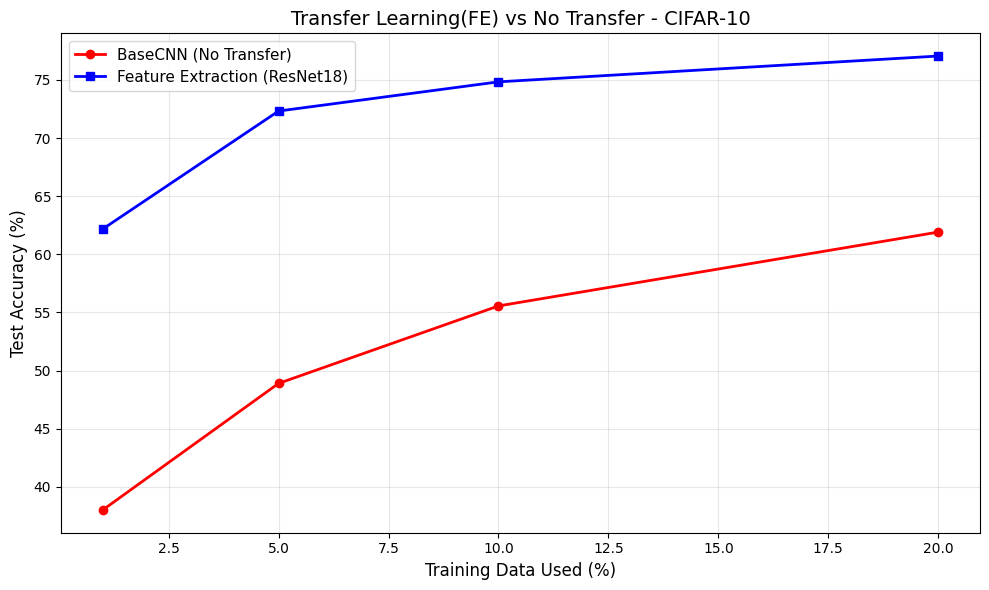

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(percentages, [cifar_baseline_results[f] for f in fractions], 'o-', linewidth=2, color='red', label='BaseCNN (No Transfer)')
plt.plot(percentages, [cifar_fe_results[f] for f in fractions], 's-', linewidth=2, color='blue', label='Feature Extraction (ResNet18)')

plt.xlabel('Training Data Used (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Transfer Learning(FE) vs No Transfer - CIFAR-10', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
cifar_ft_results = {}

for frac in fractions:
    print(f"\nFull Fine-Tuning - {frac*100}% data ({int(len(train_data_cifar)*frac)} samples)")
    
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(512, 10)
    
    subset = get_sparse_subset(train_data_cifar, frac)
    train_loader = DataLoader(subset, batch_size=32, shuffle=True)
    
    train_model(model, train_loader, epochs=5, lr=0.0001)
    acc = test_model(model, test_loader_cifar)
    cifar_ft_results[frac] = acc
    print(f"TEST ACCURACY: {acc:.2f}%")
    


Full Fine-Tuning - 1.0% data (500 samples)


c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aryan\PycharmProjects\Independent_Study\Independent_Study\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 5/5 [00:19<00:00,  3.84s/it]


TEST ACCURACY: 73.34%

Full Fine-Tuning - 5.0% data (2500 samples)


100%|██████████| 5/5 [01:49<00:00, 21.91s/it]


TEST ACCURACY: 85.79%

Full Fine-Tuning - 10.0% data (5000 samples)


100%|██████████| 5/5 [03:38<00:00, 43.79s/it]


TEST ACCURACY: 89.52%

Full Fine-Tuning - 20.0% data (10000 samples)


100%|██████████| 5/5 [06:57<00:00, 83.43s/it]


TEST ACCURACY: 90.76%


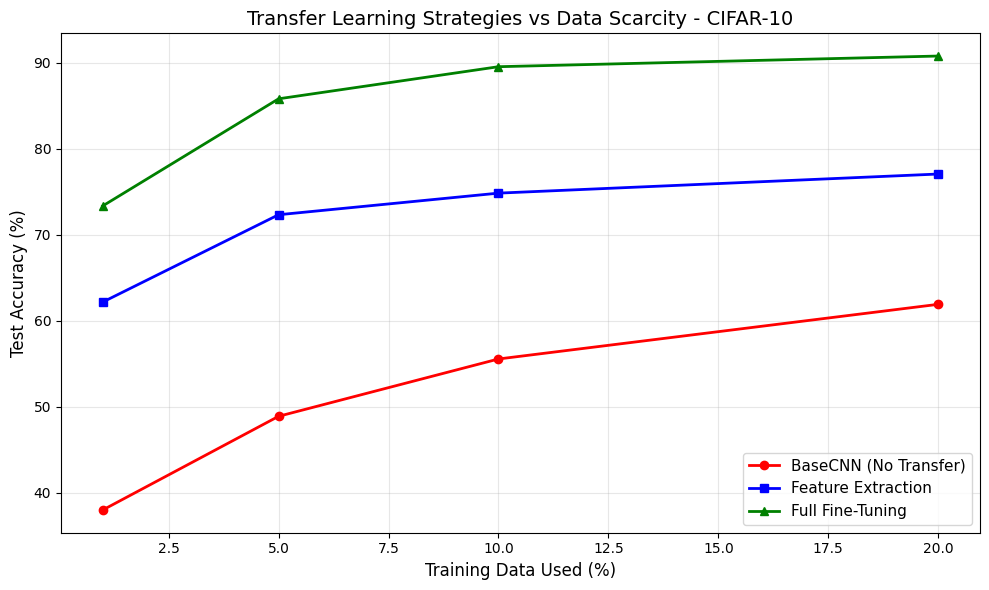

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(percentages, [cifar_baseline_results[f] for f in fractions], 'o-', linewidth=2, color='red', label='BaseCNN (No Transfer)')
plt.plot(percentages, [cifar_fe_results[f] for f in fractions], 's-', linewidth=2, color='blue', label='Feature Extraction')
plt.plot(percentages, [cifar_ft_results[f] for f in fractions], '^-', linewidth=2, color='green', label='Full Fine-Tuning')

plt.xlabel('Training Data Used (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Transfer Learning Strategies vs Data Scarcity - CIFAR-10', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## EMNIST

In [71]:
# EMNIST transforms
transform_emnist_base = transforms.Compose([
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

transform_emnist_resnet = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

# load both versions
train_emnist_base = datasets.EMNIST(root='./data', split='letters', train=True, download=True, transform=transform_emnist_base)
test_emnist_base = datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=transform_emnist_base)

train_emnist_resnet = datasets.EMNIST(root='./data', split='letters', train=True, download=True, transform=transform_emnist_resnet)
test_emnist_resnet = datasets.EMNIST(root='./data', split='letters', train=False, download=True, transform=transform_emnist_resnet)

test_loader_emnist_base = DataLoader(test_emnist_base, batch_size=64, shuffle=False)
test_loader_emnist_resnet = DataLoader(test_emnist_resnet, batch_size=32, shuffle=False)

num_classes_emnist = 27  # 26 letters + 1

print(f"Train: {len(train_emnist_base)}, Test: {len(test_emnist_base)}")
print(f"Classes: {num_classes_emnist}")



Train: 124800, Test: 20800
Classes: 27


In [72]:
fractions = [0.01, 0.05, 0.1, 0.2]

# Baseline
emnist_baseline_results = {}
for frac in fractions:
    print(f"\nBaseline - {frac*100}% data")
    model = BaseCNN(num_classes=num_classes_emnist)
    subset = get_sparse_subset(train_emnist_base, frac)
    loader = DataLoader(subset, batch_size=64, shuffle=True)
    train_model(model, loader, epochs=5, lr=0.001)
    acc = test_model(model, test_loader_emnist_base)
    emnist_baseline_results[frac] = acc
    print(f"ACCURACY: {acc:.2f}%")



Baseline - 1.0% data


100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


ACCURACY: 68.39%

Baseline - 5.0% data


100%|██████████| 5/5 [00:10<00:00,  2.04s/it]


ACCURACY: 86.69%

Baseline - 10.0% data


100%|██████████| 5/5 [00:19<00:00,  3.86s/it]


ACCURACY: 89.04%

Baseline - 20.0% data


100%|██████████| 5/5 [00:35<00:00,  7.10s/it]


ACCURACY: 91.08%


In [75]:
# Feature Extraction
emnist_fe_results = {}
for frac in fractions:
    print(f"\nFeature Extraction - {frac*100}% data")
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(512, num_classes_emnist)
    subset = get_sparse_subset(train_emnist_resnet, frac)
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    train_model(model, loader, epochs=5, lr=0.001)
    acc = test_model(model, test_loader_emnist_resnet)
    emnist_fe_results[frac] = acc
    print(f"ACCURACY: {acc:.2f}%")



Feature Extraction - 1.0% data


100%|██████████| 5/5 [00:15<00:00,  3.15s/it]


ACCURACY: 62.02%

Feature Extraction - 5.0% data


100%|██████████| 5/5 [01:50<00:00, 22.09s/it]


ACCURACY: 76.73%

Feature Extraction - 10.0% data


100%|██████████| 5/5 [03:35<00:00, 43.15s/it]


ACCURACY: 79.36%

Feature Extraction - 20.0% data


100%|██████████| 5/5 [07:09<00:00, 85.80s/it] 


ACCURACY: 81.62%


In [ ]:
emnist_ft_results = {}
for frac in fractions:
    print(f"\nFull Fine-Tuning - {frac*100}% data")
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(512, num_classes_emnist)
    subset = get_sparse_subset(train_emnist_resnet, frac)
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    train_model(model, loader, epochs=5, lr=0.0001)
    acc = test_model(model, test_loader_emnist_resnet)
    emnist_ft_results[frac] = acc
    print(f"ACCURACY: {acc:.2f}%")

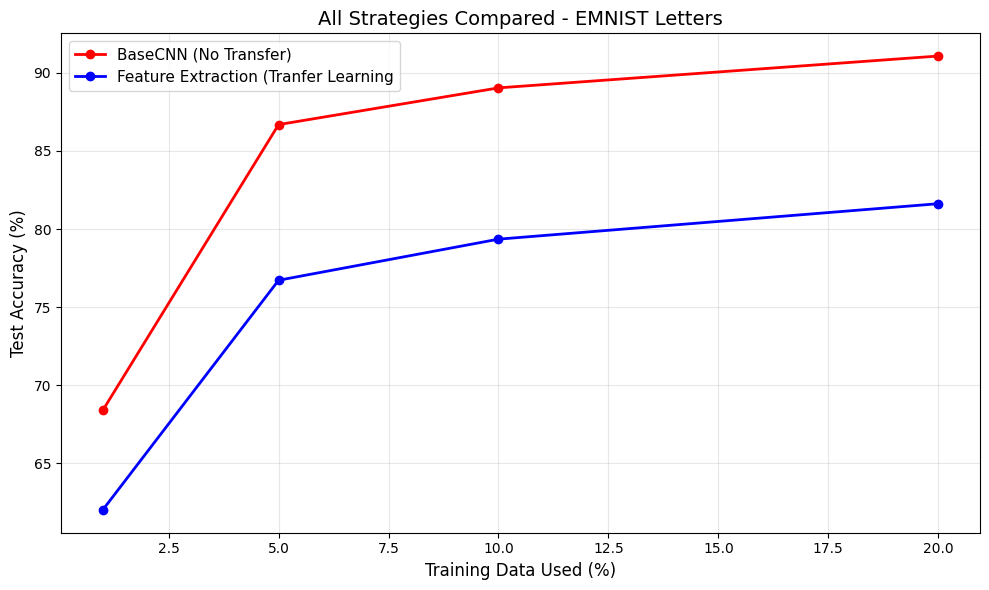

In [78]:
plt.figure(figsize=(10, 6))
plt.plot(percentages, [emnist_baseline_results[f] for f in fractions], 'o-', linewidth=2, color='red', label='BaseCNN (No Transfer)')
plt.plot(percentages, [emnist_fe_results[f] for f in fractions], 'o-', linewidth=2, color='blue', label='Feature Extraction (Tranfer Learning')

plt.xlabel('Training Data Used (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('All Strategies Compared - EMNIST Letters', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_strategies_emnist.png', dpi=150)
plt.show()